In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!nvidia-smi

Wed May 27 05:28:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [4]:
BASE_PATH = "/kaggle/input/datasets"

print(os.listdir(BASE_PATH))

['alekhya7gangopadhyay']


In [7]:
BASE_PATH = "/kaggle/input/datasets/alekhya7gangopadhyay"

In [8]:
print(os.listdir(BASE_PATH))

['eeg-dataset']


In [9]:
BASE_PATH = "/kaggle/input/datasets/alekhya7gangopadhyay/eeg-dataset"
print(os.listdir(BASE_PATH))

['content']


In [14]:
BASE_PATH = "/kaggle/input/datasets/alekhya7gangopadhyay/eeg-dataset/content/drive/My Drive/Human Computer Interface (HCI)/Chebyshev Filtered Data"
print(os.listdir(BASE_PATH))

['Backward', 'Right', 'Left', 'Forward']


In [18]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# ============================================================
# DATASET PATH
# ============================================================

BASE_PATH = (
    "/kaggle/input/datasets/"
    "alekhya7gangopadhyay/"
    "eeg-dataset/content/"
    "drive/My Drive/"
    "Human Computer Interface (HCI)/"
    "Chebyshev Filtered Data"
)

# ============================================================
# CHANNELS
# ============================================================

SELECTED_CHANNELS = [
    'P4 - O2',
    'P3 - O1',
    'F4 - C4'
]

# ============================================================
# LABELS
# ============================================================

label_map = {
    "Right": 0,
    "Left": 1,
    "Forward": 2,
    "Backward": 3
}

# ============================================================
# SETTINGS
# ============================================================

SEQUENCE_LENGTH = 256

STRIDE = 128

MAX_FILES_PER_CLASS = 500

# ============================================================
# CREATE SEQUENCES
# ============================================================

def create_sequences(data, seq_len, stride):

    sequences = []

    for start in range(
        0,
        len(data) - seq_len + 1,
        stride
    ):

        seq = data[start:start + seq_len]

        sequences.append(seq)

    return sequences

# ============================================================
# LOAD DATA
# ============================================================

X = []
y = []

print("\n================================================")
print("LOADING EEG DATA")
print("================================================\n")

for class_name, label in label_map.items():

    folder = os.path.join(
        BASE_PATH,
        class_name
    )

    files = sorted([
        f for f in os.listdir(folder)
        if f.endswith(".xlsx")
    ])

    # ========================================================
    # LIMIT FILES
    # ========================================================

    files = files[:MAX_FILES_PER_CLASS]

    print(f"{class_name}: {len(files)} files")

    # ========================================================
    # PROCESS FILES
    # ========================================================

    for idx, file_name in enumerate(files):

        try:

            path = os.path.join(
                folder,
                file_name
            )

            # =================================================
            # READ ONLY REQUIRED COLUMNS
            # =================================================

            df = pd.read_excel(
                path,
                usecols=SELECTED_CHANNELS,
                engine='openpyxl'
            )

            data = df.values.astype(np.float32)

            # =================================================
            # CREATE SEQUENCES
            # =================================================

            sequences = create_sequences(
                data,
                SEQUENCE_LENGTH,
                STRIDE
            )

            for seq in sequences:

                X.append(seq)

                y.append(label)

            # =================================================
            # PROGRESS
            # =================================================

            if (idx + 1) % 20 == 0:

                print(
                    f"{class_name} | "
                    f"{idx+1}/{len(files)} processed"
                )

        except Exception as e:

            print(f"Error: {file_name}")
            print(e)

# ============================================================
# NUMPY
# ============================================================

X = np.array(X, dtype=np.float32)

y = np.array(y)

print("\n================================================")
print("DATASET CREATED")
print("================================================")

print("X shape:", X.shape)
print("y shape:", y.shape)

# ============================================================
# NORMALIZATION
# ============================================================

samples = X.shape[0]

seq_len = X.shape[1]

channels = X.shape[2]

scaler = StandardScaler()

X_reshaped = X.reshape(-1, channels)

X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(
    samples,
    seq_len,
    channels
)

# ============================================================
# SAVE
# ============================================================

np.save("/kaggle/working/X.npy", X)

np.save("/kaggle/working/y.npy", y)

print("\nSaved:")
print("/kaggle/working/X.npy")
print("/kaggle/working/y.npy")


LOADING EEG DATA

Right: 500 files
Right | 20/500 processed
Right | 40/500 processed
Right | 60/500 processed
Right | 80/500 processed
Right | 100/500 processed
Right | 120/500 processed
Right | 140/500 processed
Right | 160/500 processed
Right | 180/500 processed
Right | 200/500 processed
Right | 220/500 processed
Right | 240/500 processed
Right | 260/500 processed
Right | 280/500 processed
Right | 300/500 processed
Right | 320/500 processed
Right | 340/500 processed
Right | 360/500 processed
Right | 380/500 processed
Right | 400/500 processed
Right | 420/500 processed
Right | 440/500 processed
Right | 460/500 processed
Right | 480/500 processed
Right | 500/500 processed
Left: 500 files
Left | 20/500 processed
Left | 40/500 processed
Left | 60/500 processed
Left | 80/500 processed
Left | 100/500 processed
Left | 120/500 processed
Left | 140/500 processed
Left | 160/500 processed
Left | 180/500 processed
Left | 200/500 processed
Left | 220/500 processed
Left | 240/500 processed
Left |

In [19]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# ============================================================
# DATASET PATH
# ============================================================

BASE_PATH = (
    "/kaggle/input/datasets/"
    "alekhya7gangopadhyay/"
    "eeg-dataset/content/"
    "drive/My Drive/"
    "Human Computer Interface (HCI)/"
    "Chebyshev Filtered Data"
)

# ============================================================
# LOAD EXISTING DATASET
# ============================================================

X_existing = np.load("/kaggle/working/X.npy")

y_existing = np.load("/kaggle/working/y.npy")

print("Existing dataset loaded:")
print(X_existing.shape)
print(y_existing.shape)

# ============================================================
# CHANNELS
# ============================================================

SELECTED_CHANNELS = [
    'P4 - O2',
    'P3 - O1',
    'F4 - C4'
]

# ============================================================
# LABELS
# ============================================================

label_map = {
    "Right": 0,
    "Left": 1,
    "Forward": 2,
    "Backward": 3
}

# ============================================================
# REQUIRED FILES
# ============================================================

required_files = {

    "Right": [

        "chebyshev_ARROW_Right.xlsx",
        "chebyshev_LETTER_Right.xlsx",
        "chebyshev_WORD_Right.xlsx",
        "chebyshev_Right ARROW2.xlsx",
        "chebyshev_Right LETTER2.xlsx",
        "chebyshev_Right WORD2.xlsx"
    ],

    "Left": [

        "chebyshev_ARROW_Left.xlsx",
        "chebyshev_LETTER_Left.xlsx",
        "chebyshev_WORD_Left.xlsx",
        "chebyshev_ARROW_Left_2.xlsx",
        "chebyshev_LETTER_Left_2.xlsx",
        "chebyshev_WORD_Left_2.xlsx"
    ],

    "Forward": [

        "chebyshev_ARROW_Forward.xlsx",
        "chebyshev_LETTER_Forward.xlsx",
        "chebyshev_WORD_Forward.xlsx",
        "chebyshev_ARROW_Forward_2.xlsx",
        "chebyshev_LETTER_Forward_2.xlsx",
        "chebyshev_WORD_Forward_2.xlsx"
    ],

    "Backward": [

        "chebyshev_ARROW_Backward.xlsx",
        "chebyshev_LETTER_Backward.xlsx",
        "chebyshev_WORD_Backword.xlsx",
        "chebyshev_ARROW_Backword_2.xlsx",
        "chebyshev_LETTER_Backward_2.xlsx",
        "chebyshev_WORD_Backward_2.xlsx"
    ]
}

# ============================================================
# SETTINGS
# ============================================================

SEQUENCE_LENGTH = 256

STRIDE = 128

# ============================================================
# CREATE SEQUENCES
# ============================================================

def create_sequences(data, seq_len, stride):

    sequences = []

    for start in range(
        0,
        len(data) - seq_len + 1,
        stride
    ):

        seq = data[start:start + seq_len]

        sequences.append(seq)

    return sequences

# ============================================================
# PROCESS REQUIRED FILES
# ============================================================

X_new = []
y_new = []

print("\nProcessing required original EEG files...\n")

for class_name, label in label_map.items():

    folder = os.path.join(
        BASE_PATH,
        class_name
    )

    for file_name in required_files[class_name]:

        try:

            path = os.path.join(
                folder,
                file_name
            )

            df = pd.read_excel(
                path,
                usecols=SELECTED_CHANNELS,
                engine='openpyxl'
            )

            data = df.values.astype(np.float32)

            sequences = create_sequences(
                data,
                SEQUENCE_LENGTH,
                STRIDE
            )

            for seq in sequences:

                X_new.append(seq)
                y_new.append(label)

            print(f"Added: {file_name}")

        except Exception as e:

            print(f"Missing/Error: {file_name}")
            print(e)

# ============================================================
# CONVERT TO NUMPY
# ============================================================

X_new = np.array(X_new, dtype=np.float32)

y_new = np.array(y_new)

print("\nNew sequences:")
print(X_new.shape)
print(y_new.shape)

# ============================================================
# NORMALIZE NEW DATA
# ============================================================

samples = X_new.shape[0]
seq_len = X_new.shape[1]
channels = X_new.shape[2]

scaler = StandardScaler()

X_reshaped = X_new.reshape(-1, channels)

X_scaled = scaler.fit_transform(X_reshaped)

X_new = X_scaled.reshape(
    samples,
    seq_len,
    channels
)

# ============================================================
# APPEND DATASETS
# ============================================================

X_final = np.concatenate(
    [X_existing, X_new],
    axis=0
)

y_final = np.concatenate(
    [y_existing, y_new],
    axis=0
)

print("\nFinal dataset:")
print(X_final.shape)
print(y_final.shape)

# ============================================================
# SAVE UPDATED DATASET
# ============================================================

np.save("/kaggle/working/X_updated.npy", X_final)

np.save("/kaggle/working/y_updated.npy", y_final)

print("\nSaved:")
print("/kaggle/working/X_updated.npy")
print("/kaggle/working/y_updated.npy")

Existing dataset loaded:
(158000, 256, 3)
(158000,)

Processing required original EEG files...

Added: chebyshev_ARROW_Right.xlsx
Added: chebyshev_LETTER_Right.xlsx
Added: chebyshev_WORD_Right.xlsx
Added: chebyshev_Right ARROW2.xlsx
Added: chebyshev_Right LETTER2.xlsx
Added: chebyshev_Right WORD2.xlsx
Added: chebyshev_ARROW_Left.xlsx
Added: chebyshev_LETTER_Left.xlsx
Added: chebyshev_WORD_Left.xlsx
Added: chebyshev_ARROW_Left_2.xlsx
Added: chebyshev_LETTER_Left_2.xlsx
Added: chebyshev_WORD_Left_2.xlsx
Added: chebyshev_ARROW_Forward.xlsx
Added: chebyshev_LETTER_Forward.xlsx
Added: chebyshev_WORD_Forward.xlsx
Added: chebyshev_ARROW_Forward_2.xlsx
Added: chebyshev_LETTER_Forward_2.xlsx
Added: chebyshev_WORD_Forward_2.xlsx
Added: chebyshev_ARROW_Backward.xlsx
Added: chebyshev_LETTER_Backward.xlsx
Added: chebyshev_WORD_Backword.xlsx
Added: chebyshev_ARROW_Backword_2.xlsx
Added: chebyshev_LETTER_Backward_2.xlsx
Added: chebyshev_WORD_Backward_2.xlsx

New sequences:
(1880, 256, 3)
(1880,)

Fin

Loading dataset...

Dataset Loaded Successfully
X shape: (159880, 256, 3)
y shape: (159880,)

Normalizing dataset...
Normalization Complete

Splitting dataset...
Train Shape: (127904, 256, 3)
Test Shape : (31976, 256, 3)

Using device: cpu

EEG_LSTM(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=4, bias=True)
  )
)

TRAINING STARTED

Epoch [1/10] | Loss: 1.3165 | Train Acc: 35.24% | Test Acc: 44.35%
Epoch [2/10] | Loss: 1.3755 | Train Acc: 27.63% | Test Acc: 27.20%
Epoch [3/10] | Loss: 0.9122 | Train Acc: 59.57% | Test Acc: 82.60%
Epoch [4/10] | Loss: 0.3648 | Train Acc: 87.81% | Test Acc: 90.71%
Epoch [5/10] | Loss: 0.2431 | Train Acc: 91.69% | Test Acc: 92.88%
Epoch [6/10] | Loss: 0.2059 | Train Acc: 93.07% | Test Acc: 94.47%
Epoch [7/10] | Loss: 0.1767 | Train Acc: 94.03% | Test Acc: 9

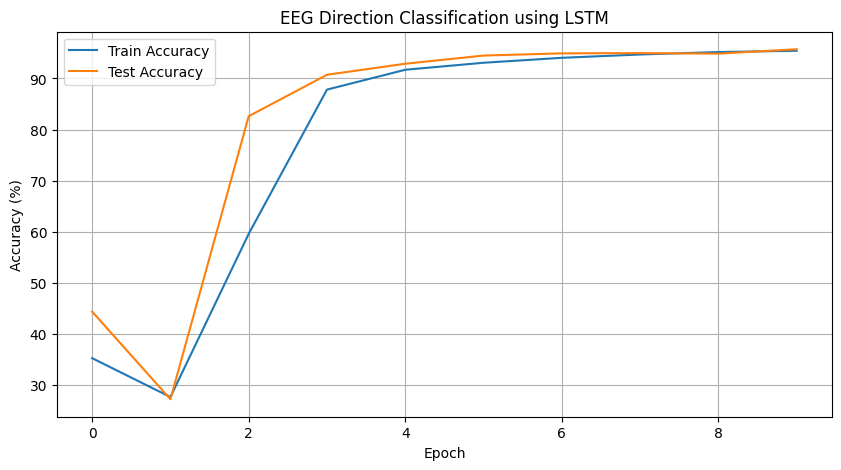

In [22]:
# ============================================================
# EEG DIRECTION CLASSIFICATION USING LSTM
# FULL CORRECTED VERSION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# ============================================================
# LOAD DATA
# ============================================================

print("Loading dataset...\n")

X = np.load("/kaggle/working/X_updated.npy")

y = np.load("/kaggle/working/y_updated.npy")

print("Dataset Loaded Successfully")

print("X shape:", X.shape)
print("y shape:", y.shape)

# ============================================================
# NORMALIZE ENTIRE DATASET CORRECTLY
# ============================================================

print("\nNormalizing dataset...")

samples = X.shape[0]
seq_len = X.shape[1]
channels = X.shape[2]

scaler = StandardScaler()

X_reshaped = X.reshape(-1, channels)

X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(
    samples,
    seq_len,
    channels
)

print("Normalization Complete")

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

print("\nSplitting dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ============================================================
# CONVERT TO TENSORS
# ============================================================

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ============================================================
# DEVICE
# ============================================================

# FORCE CPU BECAUSE P100 IS INCOMPATIBLE
device = torch.device('cpu')

print("\nUsing device:", device)

# ============================================================
# LSTM MODEL
# ============================================================

class EEG_LSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=3,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Sequential(

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(32, 4)
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

model = EEG_LSTM().to(device)

print("\n================================================")
print(model)
print("================================================")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================================
# TRAINING SETTINGS
# ============================================================

EPOCHS = 10

train_accuracies = []
test_accuracies = []

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n================================================")
print("TRAINING STARTED")
print("================================================\n")

for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_loss = 0

    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)

        y_batch = y_batch.to(device)

        # ====================================================
        # FORWARD
        # ====================================================

        outputs = model(x_batch)

        loss = criterion(outputs, y_batch)

        # ====================================================
        # BACKPROP
        # ====================================================

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ====================================================
        # METRICS
        # ====================================================

        running_loss += (
            loss.item() * x_batch.size(0)
        )

        _, preds = torch.max(outputs, 1)

        train_correct += (
            preds == y_batch
        ).sum().item()

        train_total += y_batch.size(0)

    # ========================================================
    # EPOCH TRAIN METRICS
    # ========================================================

    epoch_loss = running_loss / train_total

    train_acc = (
        100 * train_correct / train_total
    )

    train_accuracies.append(train_acc)

    # ========================================================
    # TESTING
    # ========================================================

    model.eval()

    test_correct = 0
    test_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for x_batch, y_batch in test_loader:

            x_batch = x_batch.to(device)

            y_batch = y_batch.to(device)

            outputs = model(x_batch)

            _, preds = torch.max(outputs, 1)

            test_correct += (
                preds == y_batch
            ).sum().item()

            test_total += y_batch.size(0)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                y_batch.cpu().numpy()
            )

    # ========================================================
    # TEST ACCURACY
    # ========================================================

    test_acc = (
        100 * test_correct / test_total
    )

    test_accuracies.append(test_acc)

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n================================================")
print("FINAL RESULTS")
print("================================================")

print(
    f"\nFinal Train Accuracy: "
    f"{train_accuracies[-1]:.2f}%"
)

print(
    f"Final Test Accuracy : "
    f"{test_accuracies[-1]:.2f}%"
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n================================================")
print("CLASSIFICATION REPORT")
print("================================================\n")

target_names = [
    "Right",
    "Left",
    "Forward",
    "Backward"
]

print(classification_report(
    all_labels,
    all_preds,
    target_names=target_names
))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix:\n")

print(cm)

# ============================================================
# SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "/kaggle/working/eeg_lstm_model.pth"
)

print("\nModel Saved Successfully")

print("/kaggle/working/eeg_lstm_model.pth")

# ============================================================
# ACCURACY PLOT
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_accuracies,
    label='Train Accuracy'
)

plt.plot(
    test_accuracies,
    label='Test Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "EEG Direction Classification using LSTM"
)

plt.legend()

plt.grid(True)

plt.show()

<Figure size 800x800 with 0 Axes>

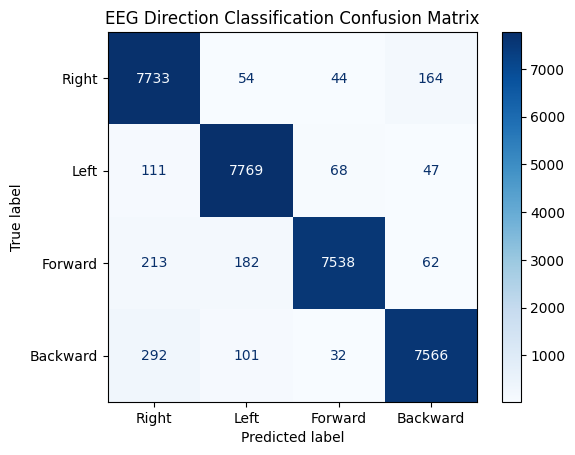

Confusion matrix saved at:
/kaggle/working/confusion_matrix.png


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_preds
)

class_names = [
    "Right",
    "Left",
    "Forward",
    "Backward"
]

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues')

plt.title(
    "EEG Direction Classification Confusion Matrix"
)

save_path = "/kaggle/working/confusion_matrix.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Confusion matrix saved at:\n{save_path}")

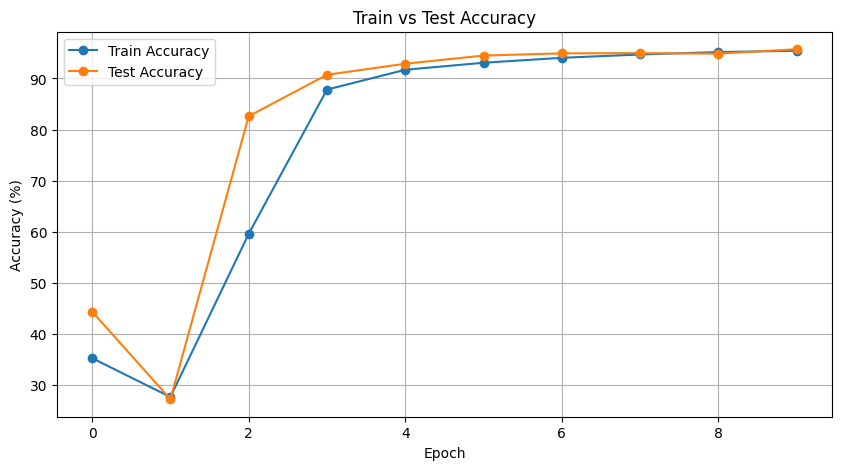

Plot saved successfully!
/kaggle/working/train_test_accuracy_plot.png


In [24]:

plt.figure(figsize=(10,5))

plt.plot(
    train_accuracies,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    test_accuracies,
    marker='o',
    label='Test Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title(
    "Train vs Test Accuracy"
)

plt.legend()

plt.grid(True)

save_path = "/kaggle/working/train_test_accuracy_plot.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Plot saved successfully!")

print(save_path)